# Train and Compare Models for Trading (HFT-Oriented)

This notebook trains multiple models on your dataset and compares them with both prediction metrics and trading-oriented proxy metrics.

Supported flow:
- Regression dataset (`target_return` present): `xgboost`, `lstm`, `cnn`, `transformer`
- Classification dataset (`label` present): `xgboost_classifier` (+ optional sklearn baselines)

Default dataset path points to `../../data/train_dataset_btcusdt_h30.csv`.

Trading proxy metrics (regression mode):
- `gross_bps`: average signed return in bps from model-driven side
- `net_bps`: `gross_bps` minus turnover cost estimate
- `turnover`: average absolute position change per step
- `coverage`: fraction of rows where model emits non-flat signal

## Potential Models for HFT

Practical model families to consider:
- Tree/tabular: XGBoost, LightGBM, CatBoost for fast retraining and strong tabular baseline
- Sequence deep nets: LSTM, TCN/CNN-1D, lightweight Transformer for short-horizon order-flow dynamics
- Linear/online: logistic/ridge/online SGD for ultra-low-latency and high stability
- Hybrid stack: fast linear gate + deep model confirmation layer for execution control

For production HFT, choose not only by RMSE/F1 but by:
- net bps after cost
- turnover and stability
- inference latency budget and tail latency

In [1]:
from __future__ import annotations

import os
import math
import sys
from pathlib import Path

# Runtime stability guard for native libs (NumPy / BLAS / Torch / XGBoost).
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)

# Ensure notebook can import modules from ml_pipeline/.
NOTEBOOK_DIR = Path.cwd()
PIPELINE_DIR = NOTEBOOK_DIR.parent
if str(PIPELINE_DIR) not in sys.path:
    sys.path.insert(0, str(PIPELINE_DIR))

from common import FEATURE_COLUMNS
from lstm_model import build_sequence_model

try:
    from xgboost import XGBRegressor, XGBClassifier
except Exception:
    XGBRegressor = None
    XGBClassifier = None

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)
except Exception:
    torch = None

pd.set_option("display.max_columns", 200)
np.random.seed(42)

In [2]:
DATASET_CSV = Path("../../data/train_dataset_btcusdt_h30.csv")
TEST_SIZE = 0.2
RANDOM_STATE = 42
HFT_TRADE_COST_BPS = 1.0
SIGNAL_THRESHOLD = 0.0  # on predicted return
SEQ_LEN = 60
EPOCHS = 5
BATCH_SIZE = 128
HIDDEN_SIZE = 64
NUM_LAYERS = 5
DROPOUT = 0.1
LEARNING_RATE = 0.01
SEQUENCE_MODELS = ["lstm", "cnn", "transformer"]

assert DATASET_CSV.exists(), f"Dataset not found: {DATASET_CSV}"
ds = pd.read_csv(DATASET_CSV)

if "target_return" in ds.columns:
    TASK = "regression"
elif "label" in ds.columns:
    TASK = "classification"
else:
    raise ValueError("Dataset must contain either 'target_return' or 'label'")

missing_features = [c for c in FEATURE_COLUMNS if c not in ds.columns]
if missing_features:
    raise ValueError(f"Missing required feature columns: {missing_features}")

print(f"Dataset: {DATASET_CSV}")
print(f"Rows: {len(ds)}")
print(f"Task: {TASK}")
display(ds.head(3))

Dataset: ../../data/train_dataset_btcusdt_h30.csv
Rows: 3425
Task: regression


,mid_price,spread,imbalance,trade_volume,trade_imbalance,target_return,target_delta,label_eps,label,price,target_price,target_ts,ts
0,75610.6,0.1,-0.852982,0.0,0.0,0.000259,19.6,0.03,up,75610.6,75630.2,1.776560e+12,1776559594200
1,75630.2,39.3,0.999286,0.0,0.0,-0.000213,-16.1,11.79,down,75630.2,75614.1,1.776560e+12,1776559594300
2,75614.1,69.1,-0.492760,0.0,0.0,-0.000110,-8.3,20.73,neutral,75614.1,75605.8,1.776560e+12,1776559594400


In [3]:
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(math.sqrt(mean_squared_error(y_true, y_pred)))
    denom = np.maximum(np.abs(y_true), 1e-8)
    mape = float(np.mean(np.abs((y_true - y_pred) / denom)))
    dir_acc = float(np.mean(np.sign(y_true) == np.sign(y_pred)))
    corr = float(np.corrcoef(y_true, y_pred)[0, 1]) if len(y_true) > 1 else 0.0
    if not np.isfinite(corr):
        corr = 0.0
    r2 = float(r2_score(y_true, y_pred))
    return {
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "directional_accuracy": dir_acc,
        "corr": corr,
        "r2": r2,
    }


def classification_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
    }


def hft_proxy_metrics_from_returns(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    trade_cost_bps: float = 1.0,
    signal_threshold: float = 0.0,
) -> dict[str, float]:
    # Position side from prediction with optional deadband.
    signal = np.where(np.abs(y_pred) > signal_threshold, np.sign(y_pred), 0.0)
    realized = signal * y_true
    gross_bps = float(np.mean(realized) * 1e4)

    if len(signal) > 1:
        turnover = float(np.mean(np.abs(np.diff(signal))))
    else:
        turnover = 0.0

    est_cost_bps = float(turnover * trade_cost_bps)
    net_bps = float(gross_bps - est_cost_bps)
    coverage = float(np.mean(signal != 0.0))

    std = float(np.std(realized))
    if std <= 1e-12:
        info_ratio = 0.0
    else:
        info_ratio = float(np.mean(realized) / std)

    return {
        "gross_bps": gross_bps,
        "net_bps": net_bps,
        "turnover": turnover,
        "coverage": coverage,
        "info_ratio": info_ratio,
    }


def make_sequence_dataset(ds_reg: pd.DataFrame, seq_len: int) -> tuple[np.ndarray, np.ndarray]:
    prices = ds_reg["price"].to_numpy(dtype=float)
    y = ds_reg["target_return"].to_numpy(dtype=float)
    if len(prices) < seq_len + 2:
        raise ValueError(f"Need at least {seq_len + 2} rows, got {len(prices)}")

    log_returns = np.log(np.maximum(prices[1:], 1e-12) / np.maximum(prices[:-1], 1e-12))
    X_list: list[np.ndarray] = []
    y_list: list[float] = []
    for i in range(seq_len, len(ds_reg)):
        seq = log_returns[i - seq_len : i]
        if len(seq) != seq_len:
            continue
        if np.isfinite(seq).all() and np.isfinite(y[i]):
            X_list.append(seq.reshape(seq_len, 1))
            y_list.append(float(y[i]))

    X = np.asarray(X_list, dtype=np.float32)
    y_out = np.asarray(y_list, dtype=np.float32)
    mean = float(X.mean())
    std = float(X.std() or 1.0)
    X = (X - mean) / std
    return X, y_out

In [4]:
results: list[dict[str, float | str | int]] = []

if TASK == "regression":
    reg_df = ds.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURE_COLUMNS + ["target_return"]).copy()
    X = reg_df[FEATURE_COLUMNS].to_numpy(dtype=float)
    y = reg_df["target_return"].to_numpy(dtype=float)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=False
    )

    if XGBRegressor is not None:
        xgb = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=400,
            learning_rate=0.03,
            max_depth=5,
            min_child_weight=20,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
        xgb.fit(X_train, y_train)
        pred = xgb.predict(X_test)
        row = {
            "model": "xgboost",
            **regression_metrics(y_test, pred),
            **hft_proxy_metrics_from_returns(
                y_test,
                pred,
                trade_cost_bps=HFT_TRADE_COST_BPS,
                signal_threshold=SIGNAL_THRESHOLD,
            ),
        }
        row.update({"train_rows": len(X_train), "test_rows": len(X_test)})
        results.append(row)
    else:
        print("xgboost not available, skipping xgboost regressor")

else:
    cls_df = ds.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURE_COLUMNS + ["label"]).copy()
    cls_df["label"] = cls_df["label"].astype(str).str.strip().str.lower()

    labels = [c for c in ["down", "neutral", "up"] if c in set(cls_df["label"]) ]
    if not labels:
        labels = sorted(cls_df["label"].unique().tolist())
    label_to_id = {label: i for i, label in enumerate(labels)}

    X = cls_df[FEATURE_COLUMNS].to_numpy(dtype=float)
    y = cls_df["label"].map(label_to_id).to_numpy(dtype=int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=False
    )

    if XGBClassifier is not None:
        xgb_cls = XGBClassifier(
            objective="multi:softprob",
            n_estimators=400,
            learning_rate=0.03,
            max_depth=5,
            min_child_weight=20,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=1,
            num_class=len(labels),
        )
        xgb_cls.fit(X_train, y_train)
        pred = xgb_cls.predict(X_test)
        row = {"model": "xgboost_classifier", **classification_metrics(y_test, pred)}
        row.update({"train_rows": len(X_train), "test_rows": len(X_test)})
        results.append(row)
    else:
        print("xgboost not available, skipping classifier")

In [5]:
if TASK == "regression":
    if torch is None:
        print("torch not available, skipping lstm/cnn/transformer")
    else:
        reg_seq_df = ds.replace([np.inf, -np.inf], np.nan).dropna(subset=["price", "target_return"]).reset_index(drop=True)
        X_seq, y_seq = make_sequence_dataset(reg_seq_df, seq_len=SEQ_LEN)

        X_train, X_test, y_train, y_test = train_test_split(
            X_seq, y_seq, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=False
        )

        for model_type in SEQUENCE_MODELS:
            torch.manual_seed(RANDOM_STATE)
            model = build_sequence_model(
                model_type=model_type,
                input_dim=int(X_train.shape[-1]),
                hidden_size=HIDDEN_SIZE,
                num_layers=NUM_LAYERS,
                dropout=DROPOUT,
                nhead=4,
            )

            optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
            loss_fn = nn.SmoothL1Loss()
            loader = DataLoader(
                TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                batch_size=BATCH_SIZE,
                shuffle=True,
            )

            model.train()
            for epoch in range(1, EPOCHS + 1):
                losses = []
                for xb, yb in loader:
                    optimizer.zero_grad(set_to_none=True)
                    pred = model(xb)
                    loss = loss_fn(pred, yb)
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    losses.append(float(loss.item()))
                if epoch in {1, EPOCHS}:
                    print(f"{model_type} epoch={epoch} loss={np.mean(losses):.8f}")

            model.eval()
            with torch.no_grad():
                pred = model(torch.from_numpy(X_test)).numpy()

            row = {
                "model": model_type,
                **regression_metrics(y_test, pred),
                **hft_proxy_metrics_from_returns(
                    y_test,
                    pred,
                    trade_cost_bps=HFT_TRADE_COST_BPS,
                    signal_threshold=SIGNAL_THRESHOLD,
                ),
            }
            row.update({"train_rows": len(X_train), "test_rows": len(X_test)})
            results.append(row)
else:
    print("Sequence models are only used in regression mode in this notebook.")

lstm epoch=1 loss=0.04481344
lstm epoch=5 loss=0.00000022
cnn epoch=1 loss=0.02253130
cnn epoch=5 loss=0.00002500
transformer epoch=1 loss=0.08903897
transformer epoch=5 loss=0.00001970


In [6]:
results_df = pd.DataFrame(results)
if results_df.empty:
    raise RuntimeError("No models were trained; check package availability and dataset schema.")

if TASK == "regression":
    results_df = results_df.sort_values(
        ["net_bps", "directional_accuracy", "rmse"],
        ascending=[False, False, True],
    ).reset_index(drop=True)
else:
    results_df = results_df.sort_values(["accuracy", "macro_f1"], ascending=False).reset_index(drop=True)

display(results_df)
print(f"Best model: {results_df.iloc[0]['model']}")

,model,mae,rmse,mape,directional_accuracy,corr,r2,gross_bps,net_bps,turnover,coverage,info_ratio,train_rows,test_rows
0,xgboost,0.000176,0.000262,256.212261,0.576642,0.590799,0.319223,1.021522,0.635557,0.385965,1.0,0.339698,2740,685
1,lstm,0.000368,0.000439,1470.045410,0.481426,0.411918,-0.958970,-0.003201,-0.003201,0.000000,1.0,-0.001020,2692,673
2,transformer,0.001601,0.001631,7667.815918,0.481426,0.067683,-26.050091,-0.003201,-0.003201,0.000000,1.0,-0.001020,2692,673
3,cnn,0.000673,0.000756,2948.237793,0.472511,0.017748,-4.816127,0.005250,-0.024512,0.029762,1.0,0.001674,2692,673


Best model: xgboost


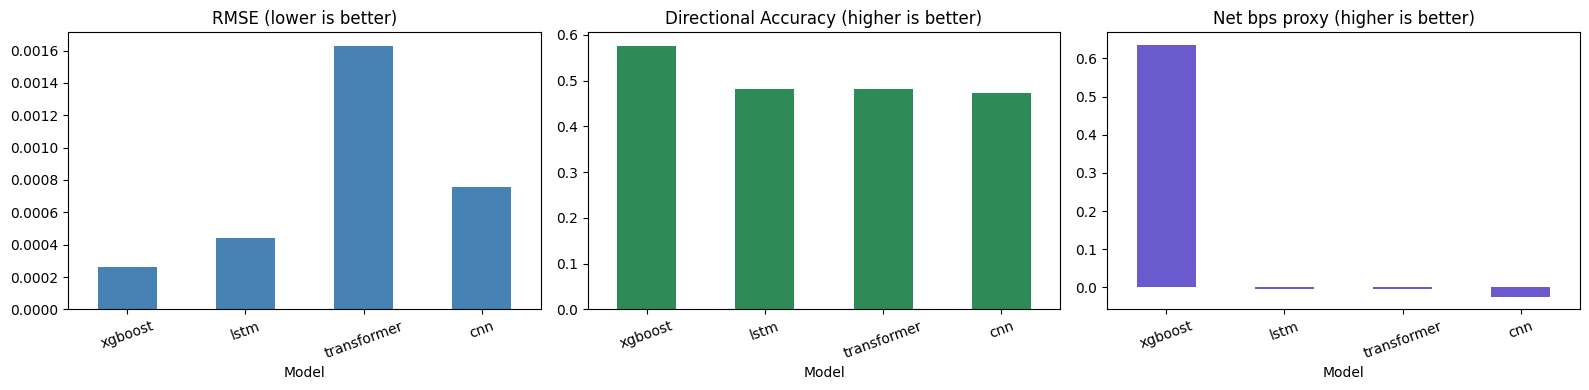

In [7]:
import matplotlib.pyplot as plt

if TASK == "regression":
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    results_df.plot(kind="bar", x="model", y="rmse", legend=False, ax=ax[0], color="steelblue")
    results_df.plot(kind="bar", x="model", y="directional_accuracy", legend=False, ax=ax[1], color="seagreen")
    results_df.plot(kind="bar", x="model", y="net_bps", legend=False, ax=ax[2], color="slateblue")
    ax[0].set_title("RMSE (lower is better)")
    ax[1].set_title("Directional Accuracy (higher is better)")
    ax[2].set_title("Net bps proxy (higher is better)")
else:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    results_df.plot(kind="bar", x="model", y="accuracy", legend=False, ax=ax[0], color="darkorange")
    results_df.plot(kind="bar", x="model", y="macro_f1", legend=False, ax=ax[1], color="mediumpurple")
    ax[0].set_title("Accuracy (higher is better)")
    ax[1].set_title("Macro F1 (higher is better)")

for a in ax:
    a.tick_params(axis="x", rotation=20)
    a.set_xlabel("Model")

plt.tight_layout()
plt.show()

In [8]:
metrics_out = Path("../../data/model_compare_metrics.csv")
metrics_out.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(metrics_out, index=False)
print(f"Saved metrics: {metrics_out}")

best = results_df.iloc[0].to_dict()
display(pd.DataFrame([best]))

Saved metrics: ../../data/model_compare_metrics.csv


,model,mae,rmse,mape,directional_accuracy,corr,r2,gross_bps,net_bps,turnover,coverage,info_ratio,train_rows,test_rows
0,xgboost,0.000176,0.000262,256.212261,0.576642,0.590799,0.319223,1.021522,0.635557,0.385965,1.0,0.339698,2740,685
